# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  1642k      0 --:--:-- --:--:-- --:--:-- 8120k


In [3]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
replace kc_house_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: kc_house_data.csv       


In [4]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv')

#X = df[['YearsExperience']].values
#y = df[['Salary']].values
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [5]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [6]:
X = df[['bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15']].values
y = df[['price']].values

### Normalização dos dados

In [7]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [8]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 18])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [9]:
model = torch.nn.Linear(18, 1)

### Verificando a inicialização dos parâmetros

In [10]:
model.weight.data

tensor([[-0.2220, -0.0462, -0.1132, -0.0629, -0.2082,  0.0946, -0.2113, -0.0150,
          0.0819, -0.0794,  0.1337,  0.0297,  0.1296,  0.1512, -0.1041,  0.0857,
         -0.1020,  0.0739]])

### Testando o predict da rede

In [11]:
model(torch.ones(5,18))

tensor([[-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072]], grad_fn=<AddmmBackward0>)

In [12]:
model(X_train_tensor[:3])

tensor([[-0.8767],
        [ 0.1813],
        [-0.6099]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [13]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

### Laço de treinamento

In [14]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [15]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [16]:
num_epochs = 3000
w0_list = [] # Stores weights
w1_list = [] # Stores biases
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # Store weights and biases for plotting later (w0 -> weight, w1 -> bias)
    w0_list.append(model.weight.data[0][0].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0) # Append 0 if no bias

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/3000], Train Loss: 1.513318, Val Loss: 1.617444
Epoch[40/3000], Train Loss: 1.198400, Val Loss: 1.290528
Epoch[60/3000], Train Loss: 0.981489, Val Loss: 1.064372
Epoch[80/3000], Train Loss: 0.830320, Val Loss: 0.906008
Epoch[100/3000], Train Loss: 0.723470, Val Loss: 0.793497
Epoch[120/3000], Train Loss: 0.646680, Val Loss: 0.712201
Epoch[140/3000], Train Loss: 0.590435, Val Loss: 0.652325
Epoch[160/3000], Train Loss: 0.548365, Val Loss: 0.607290
Epoch[180/3000], Train Loss: 0.516182, Val Loss: 0.572656
Epoch[200/3000], Train Loss: 0.490992, Val Loss: 0.545409
Epoch[220/3000], Train Loss: 0.470821, Val Loss: 0.523491
Epoch[240/3000], Train Loss: 0.454316, Val Loss: 0.505482
Epoch[260/3000], Train Loss: 0.440541, Val Loss: 0.490396
Epoch[280/3000], Train Loss: 0.428838, Val Loss: 0.477537
Epoch[300/3000], Train Loss: 0.418741, Val Loss: 0.466410
Epoch[320/3000], Train Loss: 0.409912, Val Loss: 0.456654
Epoch[340/3000], Train Loss: 0.402107, Val Loss: 0.448008
Epoch[360/3000], T

## Avaliação

In [17]:
X_train_tensor.shape

torch.Size([15129, 18])

In [18]:
X[0]

array([ 3.00000e+00,  1.00000e+00,  1.18000e+03,  5.65000e+03,
        1.00000e+00,  0.00000e+00,  0.00000e+00,  3.00000e+00,
        7.00000e+00,  1.18000e+03,  0.00000e+00,  1.95500e+03,
        0.00000e+00,  9.81780e+04,  4.75112e+01, -1.22257e+02,
        1.34000e+03,  5.65000e+03])

In [19]:
df.columns[0]

'id'

/tmp/ipykernel_12151/2227120141.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


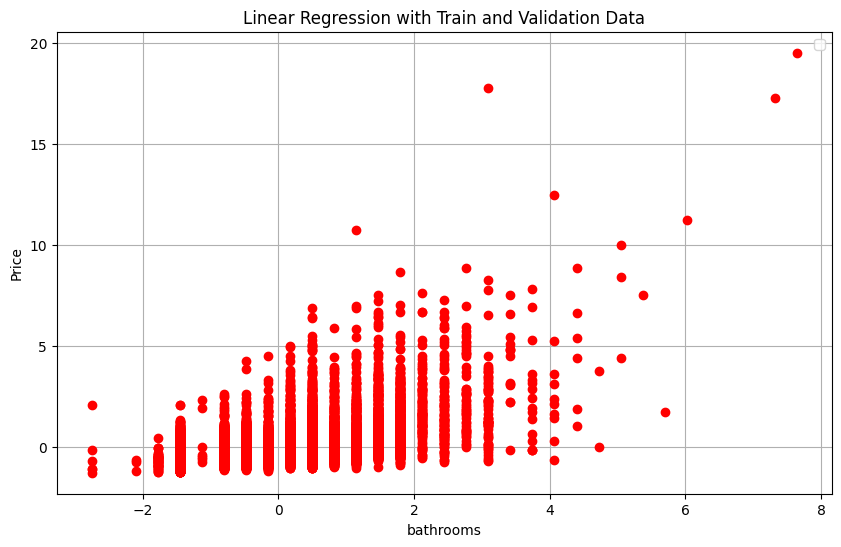

In [20]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

i = 1

plt.figure(figsize=(10, 6))

# Plot original training data
plt.plot(X_train_tensor[...,i].numpy(), y_train_tensor.numpy(), 'ro')

# Plot original validation data
#plt.plot(X_val_tensor.numpy(), y_val_tensor.numpy(), 'go', label='Original Validation Data')

# Plot fitting line for training data
#plt.plot(X_train_tensor[...,0].numpy(), y_pred_train.data.numpy(), 'k-', label='Fitting Line (Train)')

# Plot fitting line for validation data
#plt.plot(X_val_tensor.numpy(), y_pred_val.data.numpy(), 'b--', label='Fitting Line (Validation)')

plt.xlabel(f'{df.columns[i + 3]}')
plt.ylabel('Price')
plt.title('Linear Regression with Train and Validation Data')
plt.legend()
plt.grid(True)
plt.show()

 ## Nova avaliação

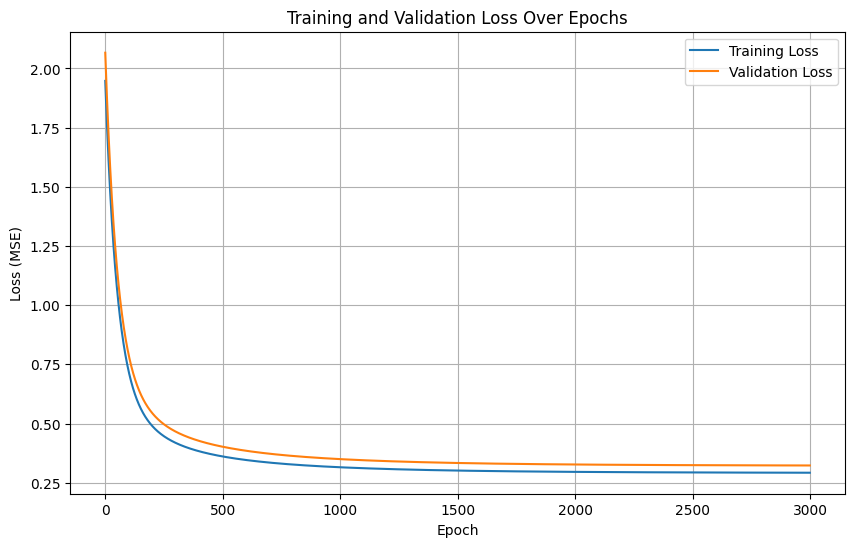

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()